# Module 2 Coding Assignment: Time Series Prediction Using LSTM


This assignment will guide you through the process of building and training a Long Short-Term Memory (LSTM) neural network to predict daily minimum temperatures using a dataset from Melbourne, Australia.



# Instructions
Follow the provided steps sequentially, executing each code cell as you go. Observe the data loading, preprocessing, model training, and evaluation stages. Pay attention to the explanations and comments within the code to understand the underlying concepts. By the end, you'll have gained hands-on experience in training and evaluating an LSTM for forecasting time series data.

## Step 1: Data Collection

* Download the dataset from the UCI Machine Learning Repository.
* Load the data and prepare it for training.


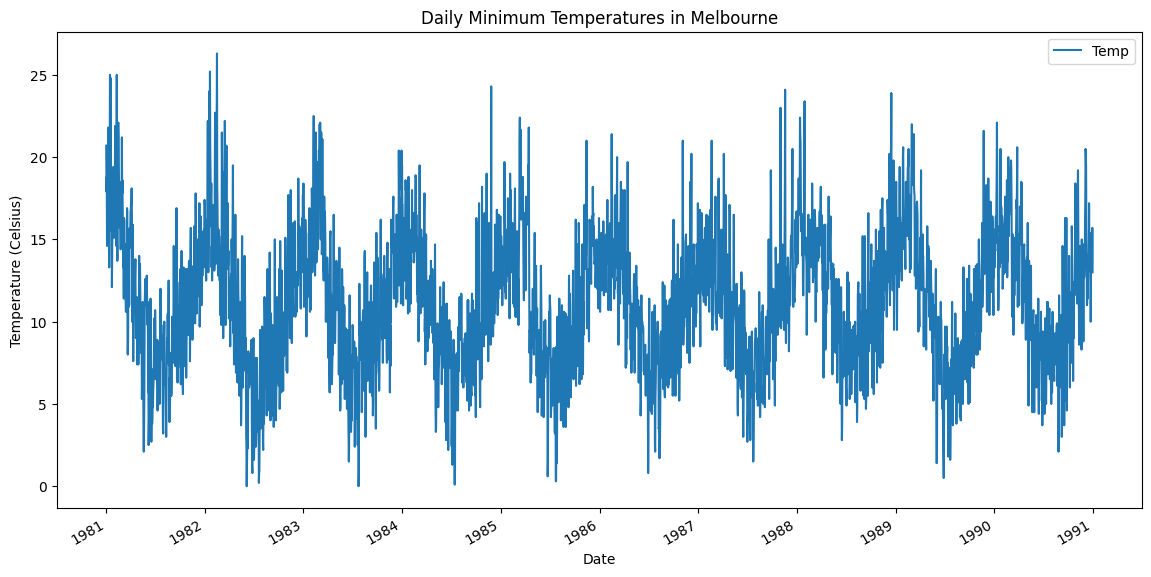

In [ ]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from sklearn.preprocessing import MinMaxScaler
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import LSTM, Dense, Dropout

# Load the dataset
url = 'https://raw.githubusercontent.com/jbrownlee/Datasets/master/daily-min-temperatures.csv'
data = pd.read_csv(url, parse_dates=['Date'], index_col='Date')

# Plot the dataset
data.plot(figsize=(14, 7))
plt.title('Daily Minimum Temperatures in Melbourne')
plt.xlabel('Date')
plt.ylabel('Temperature (Celsius)')
plt.show()


## Step 2: Data Preprocessing

* Normalize the temperature data to ensure all values are within the same range.
* Create sequences of data for the RNN.



In [ ]:
# Normalize the data
scaler = MinMaxScaler(feature_range=(0, 1))
scaled_data = scaler.fit_transform(data.values)

# Create sequences of data
def create_sequences(data, seq_length):
    xs, ys = [], []
    for i in range(len(data)-seq_length):
        x = data[i:i+seq_length]
        y = data[i+seq_length]
        xs.append(x)
        ys.append(y)
    return np.array(xs), np.array(ys)

seq_length = 50
x, y = create_sequences(scaled_data, seq_length)
x = x.reshape((x.shape[0], x.shape[1], 1))

# Split the data into training and testing sets
split = int(0.8 * len(x))
x_train, x_test = x[:split], x[split:]
y_train, y_test = y[:split], y[split:]


## Step 3: Model Building and Training
* Build an LSTM model with appropriate layers for time series prediction.
* Compile the model with an optimizer and loss function.
* Train the model using the training data.
* Set appropriate batch size and number of epochs.


In [ ]:
# Build the LSTM model
model = Sequential([
    LSTM(50, return_sequences=True, input_shape=(seq_length, 1)),
    Dropout(0.2),
    LSTM(50, return_sequences=False),
    Dropout(0.2),
    Dense(25),
    Dense(1)
])

# Compile the model
model.compile(optimizer='adam', loss='mean_squared_error')

# Train the model
model.fit(x_train, y_train, batch_size=32, epochs=20, validation_split=0.2)


Epoch 1/20
72/72 [==============================] - 10s 60ms/step - loss: 0.0211 - val_loss: 0.0116
Epoch 2/20
72/72 [==============================] - 4s 53ms/step - loss: 0.0134 - val_loss: 0.0124
Epoch 3/20
72/72 [==============================] - 6s 78ms/step - loss: 0.0129 - val_loss: 0.0113
Epoch 4/20
72/72 [==============================] - 5s 73ms/step - loss: 0.0129 - val_loss: 0.0114
Epoch 5/20
72/72 [==============================] - 7s 93ms/step - loss: 0.0123 - val_loss: 0.0115
Epoch 6/20
72/72 [==============================] - 8s 109ms/step - loss: 0.0122 - val_loss: 0.0112
Epoch 7/20
72/72 [==============================] - 4s 52ms/step - loss: 0.0120 - val_loss: 0.0109
Epoch 8/20
72/72 [==============================] - 6s 87ms/step - loss: 0.0122 - val_loss: 0.0111
Epoch 9/20
72/72 [==============================] - 4s 51ms/step - loss: 0.0120 - val_loss: 0.0110
Epoch 10/20
72/72 [==============================] - 4s 54ms/step - loss: 0.0116 - val_loss: 0.0106
Epoch 1

## Step 5: Evaluation

* Make predictions on the test set.
* Inverse transform the predictions to get them back to the original scale.
* Plot the actual vs predicted temperatures.


23/23 [==============================] - 2s 38ms/step


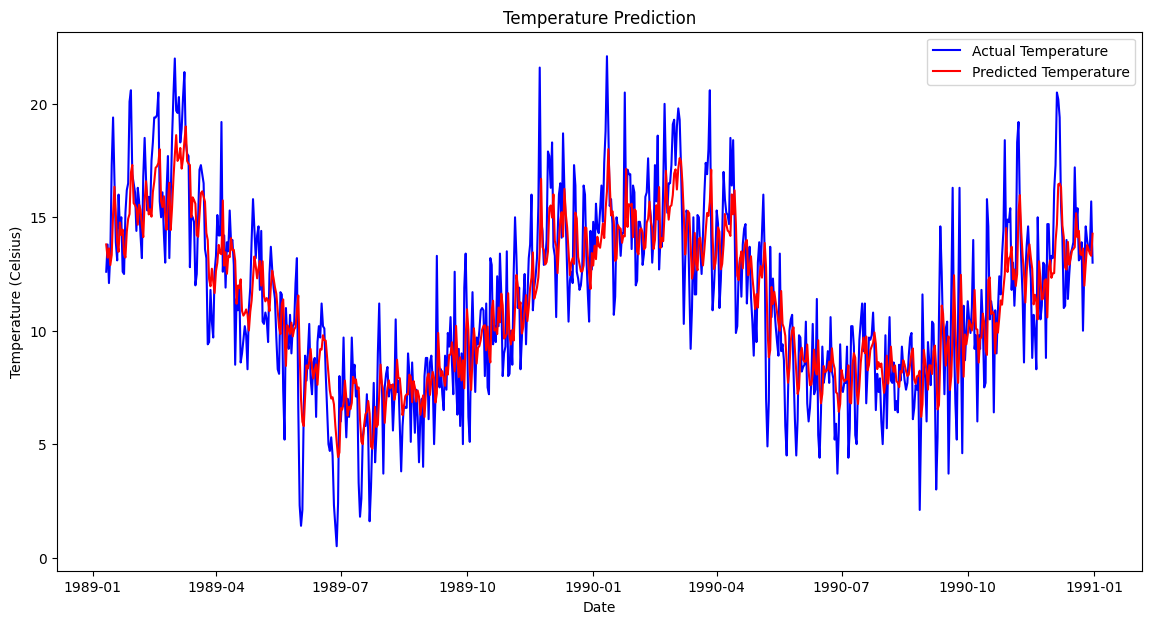

In [ ]:
# Make predictions on the test set
predictions = model.predict(x_test)
predictions = scaler.inverse_transform(predictions)
actual = scaler.inverse_transform(y_test)

# Plotting the results for the test set
plt.figure(figsize=(14,7))
plt.plot(data.index[seq_length + split:], actual, color='blue', label='Actual Temperature')
plt.plot(data.index[seq_length + split:], predictions, color='red', label='Predicted Temperature')
plt.title('Temperature Prediction')
plt.xlabel('Date')
plt.ylabel('Temperature (Celsius)')
plt.legend()
plt.show()


## Summary
In this assignment, we've walked through the process of building an RNN(LSTM) to predict the next day's temperature based on historical data. Below are some key points and additional notes to help you understand the various aspects of the project:

### Importance of Normalizing Time Series Data
Normalization is crucial in time series prediction tasks because it scales the data to a consistent range, typically between 0 and 1. This ensures that all values are within the same range, preventing any single feature from disproportionately influencing the model's predictions. In our case, we used the MinMaxScaler to normalize the temperature data.

### Feature Engineering
While this assignment focused on using historical temperatures alone, in practice, incorporating additional features can enhance model performance. For example, including attributes such as humidity, wind speed, and even external factors like seasonal trends or holidays can provide more context to the model.

### Use of Dropout Layers to Prevent Overfitting
Overfitting occurs when a model learns the training data too well, including its noise and outliers, leading to poor performance on unseen data. Dropout layers help mitigate this by randomly setting a fraction of input units to zero during training, thereby forcing the model to learn more robust features that generalize better to new data.

### Evaluation Metrics
In this project, we used Mean Squared Error (MSE) as the loss function to evaluate model performance. MSE measures the average of the squares of the errors—that is, the average squared difference between the predicted and actual values. Lower MSE values indicate better model performance.